In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import numpy as np
import scipy.stats as st
import scipy.special as sp
import scipy.signal as sig
import matplotlib.pyplot as plt

import noisefinder.noisefinder as nf
from noisefinder_freqscheme.CPSD_linMmethod import CPSD_linMmethod
%matplotlib ipympl

Text(0.5, 1.0, 'Generated data')

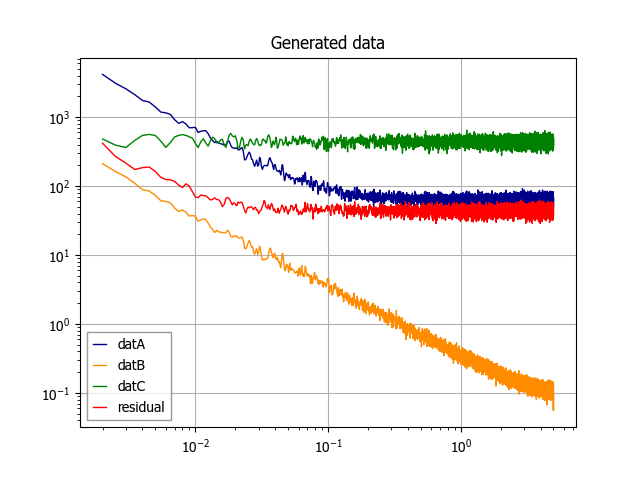

In [10]:
# just generate some data. make them correlated so that we test the entire method.
datres = np.cumsum(st.norm.rvs(size=210000))+100*st.norm.rvs(size=210000)
datB = 0.5*np.cumsum(st.norm.rvs(size=210000))
datC = 1000*st.norm.rvs(size=210000)
datA = datres+19*datB+0.10*datC
datres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
datB_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
datC_true = lambda f: 1000*np.sqrt(2/10)*f**0
datA_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [datA,datB,datC]

#calculate welch for comparison
PSDfres,PSDvres = sig.welch(datres,fs=10,window='blackmanharris',nperseg=20000)
PSDfA,PSDvA = sig.welch(datA,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = sig.welch(datB,fs=10,window='blackmanharris',nperseg=20000)
PSDfC,PSDvC = sig.welch(datC,fs=10,window='blackmanharris',nperseg=20000)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='datA')
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1,label='datB')
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1,label='datC')
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='residual')
ax.grid()
ax.legend()
ax.set_title('Generated data')

In [11]:
#calculate with linM method, for instance
meas_linMmethod = CPSD_linMmethod(ts=meas,fs=10,fmin=2e-3,fmax=1)

#extract parameters
meas_linMmethod.cohere
meas_linMmethod.CPSD
meas_linMmethod.PSD
meas_linMmethod.freqs
meas_linMmethod.Ls
meas_linMmethod.matp
meas_linMmethod.navs
meas_linMmethod.win
meas_linMmethod.winscheme

meas_linMmethod_PSDq = meas_linMmethod.PSDquantiles_eval(cval=0.68)

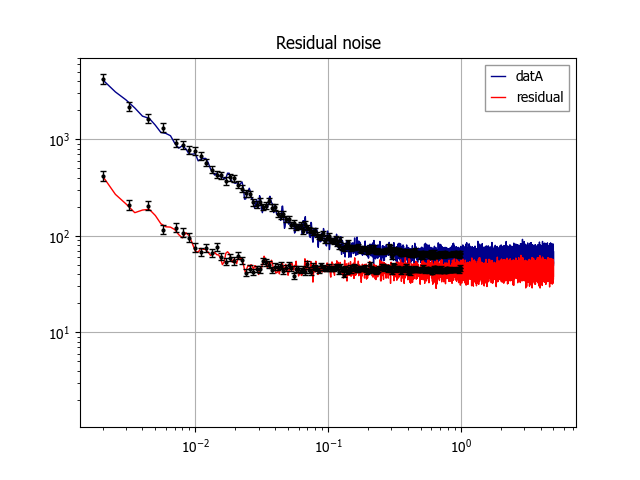

In [13]:
# now decorrelate
meas_sfnp = nf.noiseproj(meas_linMmethod)
meas_PSDq_resid,meas_alpre,meas_alpim = meas_sfnp.get_noiseprojCI(cval=0.68)

#we also want to look at coherences to understand uncertainties in alpha
meas_linMmethod_MSCq_AB = meas_linMmethod.MSCquantiles_eval(idx1=0,idx2=1,cval=0.68)
meas_linMmethod_MSCq_AC = meas_linMmethod.MSCquantiles_eval(idx1=0,idx2=2,cval=0.68)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='datA')
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='residual')

tsidx = 0
ax.errorbar(meas_linMmethod.freqs,
            np.sqrt(meas_linMmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_linMmethod_PSDq[tsidx,1,:])-np.sqrt(meas_linMmethod_PSDq[tsidx,0,:]),np.sqrt(meas_linMmethod_PSDq[tsidx,2,:])-np.sqrt(meas_linMmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2,lw=1,c='k',fmt='.',markersize=4)

ax.errorbar(meas_linMmethod.freqs,
            np.sqrt(meas_PSDq_resid[:,1]),
            yerr = [np.sqrt(meas_PSDq_resid[:,1])-np.sqrt(meas_PSDq_resid[:,0]),np.sqrt(meas_PSDq_resid[:,2])-np.sqrt(meas_PSDq_resid[:,1])],
            linestyle='',capsize=2,lw=1,c='k',fmt='.',markersize=4)

ax.grid()
ax.legend()
ax.set_title('Residual noise')
plt.show()

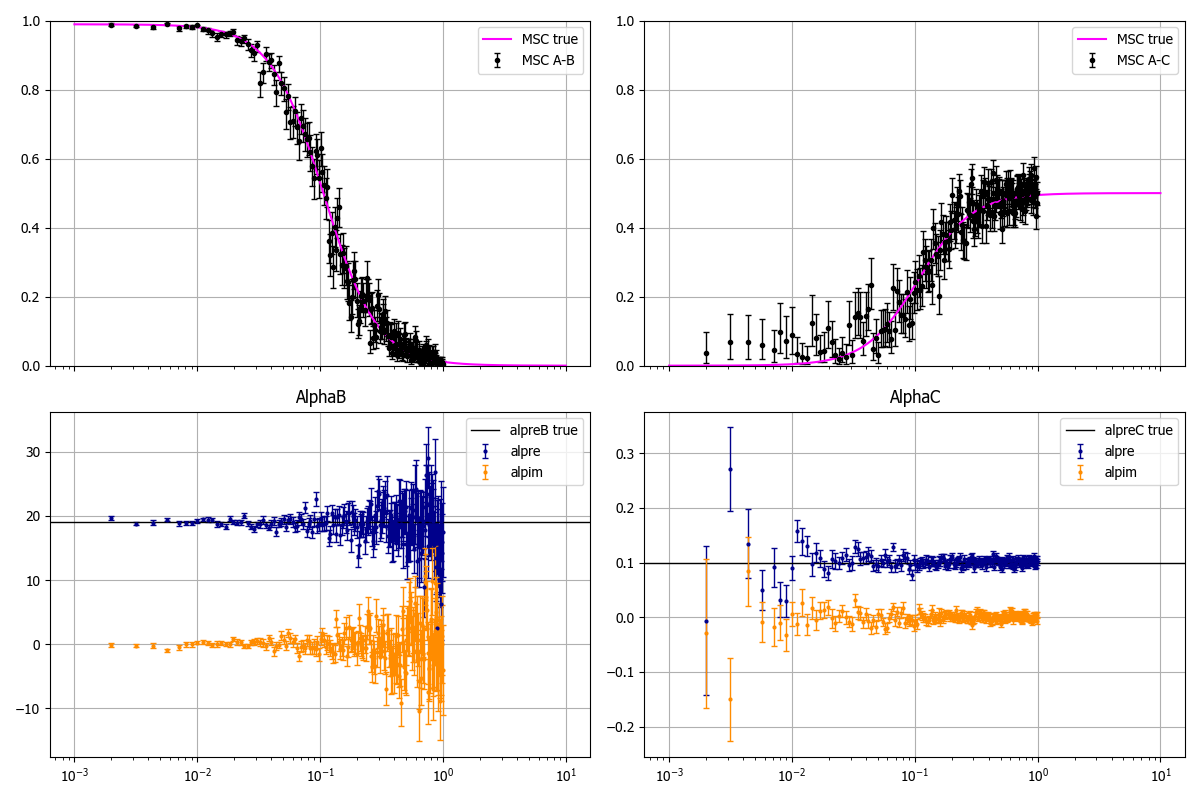

In [14]:
fig,ax=plt.subplots(2,2,figsize=(12,8),sharex=True)

#plot MSCs
MSCABtrue = lambda f: (19*datB_true(f)/datA_true(f))**2
MSCACtrue = lambda f: (0.1*datC_true(f)/datA_true(f))**2
faxis=np.logspace(-3,1,1000)
ax[0,0].errorbar(x=meas_linMmethod.freqs,
            y=meas_linMmethod_MSCq_AB[:,1],
            yerr = [meas_linMmethod_MSCq_AB[:,1]-meas_linMmethod_MSCq_AB[:,0],meas_linMmethod_MSCq_AB[:,2]-meas_linMmethod_MSCq_AB[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',label='MSC A-B')
ax[0,0].plot(faxis,MSCABtrue(faxis),c='magenta',label='MSC true')
ax[0,0].legend()
ax[0,0].grid()
ax[0,0].set_ylim([0,1])
ax[0,1].errorbar(x=meas_linMmethod.freqs,
            y=meas_linMmethod_MSCq_AC[:,1],
            yerr = [meas_linMmethod_MSCq_AC[:,1]-meas_linMmethod_MSCq_AC[:,0],meas_linMmethod_MSCq_AC[:,2]-meas_linMmethod_MSCq_AC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',label='MSC A-C')
ax[0,1].plot(faxis,MSCACtrue(faxis),c='magenta',label='MSC true')
ax[0,1].legend()
ax[0,1].grid()
ax[0,1].set_ylim([0,1])

#plot alphas
tsidx = 0
ax[1,0].errorbar(meas_linMmethod.freqs,
            meas_alpre[:,tsidx,1],
            yerr = [meas_alpre[:,tsidx,1]-meas_alpre[:,tsidx,0],meas_alpre[:,tsidx,2]-meas_alpre[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpre')
ax[1,0].axhline(19,c='k',lw=1,label='alpreB true')
ax[1,0].errorbar(meas_linMmethod.freqs,
            meas_alpim[:,tsidx,1],
            yerr = [meas_alpim[:,tsidx,1]-meas_alpim[:,tsidx,0],meas_alpim[:,tsidx,2]-meas_alpim[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpim')
ax[1,0].set_xscale('log')
ax[1,0].grid()
ax[1,0].set_title('AlphaB')
ax[1,0].legend()

tsidx = 1
ax[1,1].errorbar(meas_linMmethod.freqs,
            meas_alpre[:,tsidx,1],
            yerr = [meas_alpre[:,tsidx,1]-meas_alpre[:,tsidx,0],meas_alpre[:,tsidx,2]-meas_alpre[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpre')
ax[1,1].axhline(0.1,c='k',lw=1,label='alpreC true')
ax[1,1].errorbar(meas_linMmethod.freqs,
            meas_alpim[:,tsidx,1],
            yerr = [meas_alpim[:,tsidx,1]-meas_alpim[:,tsidx,0],meas_alpim[:,tsidx,2]-meas_alpim[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpim')
ax[1,1].set_xscale('log')
ax[1,1].set_title('AlphaC')
ax[1,1].grid()
ax[1,1].legend()
fig.tight_layout()

plt.show()